In [2]:
import sys
sys.path.insert(0, "../../")  # go up to project root so 'src' is findable


In [3]:
from src.data.dezem import load_dezem_csv, compute_window_features

train_loader, val_loader, meta = load_dezem_csv(
    "/mnt/c/Users/Hidou/Downloads/Dezem 2 years.csv",
    window_size=24
)
feats = compute_window_features(meta["values_norm"], window_size=24)
print(feats.shape)
print(feats[:3])


/home/justmouheb/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dropping 2 duplicate timestamps (keeping first)
Filling 74 missing hourly timestamps via time interpolation
Loaded 16,704 hourly points
Range: [0.59, 1453.01]  Mean: 164.88  Std: 244.29
Windows — train: 13,340  val: 3,318  (window=24h, stride=1)
(16681, 3)
[[-0.6652067   0.00092833 -0.09526749]
 [-0.6651606   0.00090468 -0.19945922]
 [-0.6650608   0.00094387 -0.26312804]]


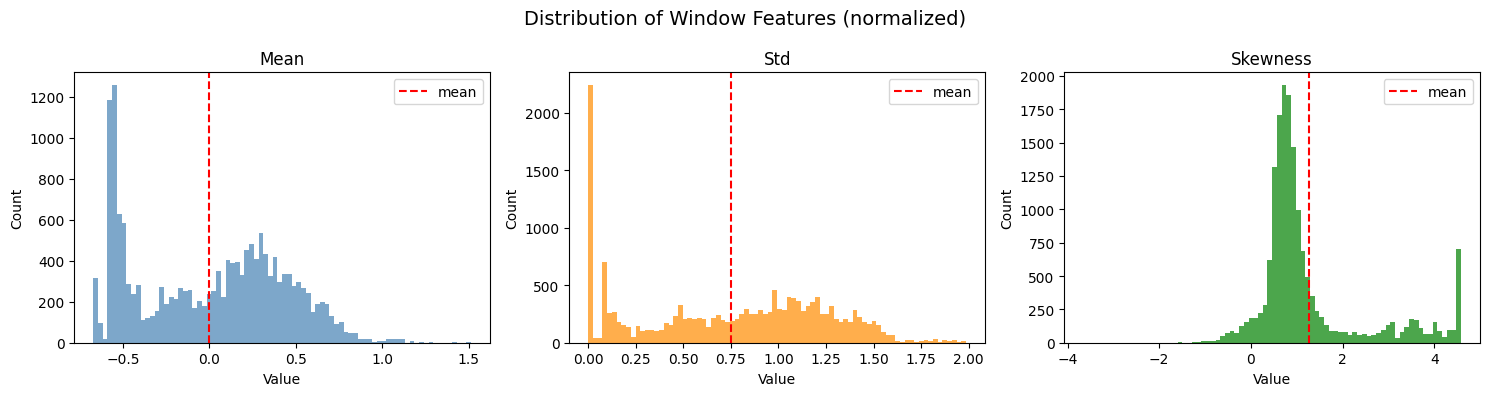

Saved plot.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution of Window Features (normalized)", fontsize=14)

names = ["Mean", "Std", "Skewness"]
colors = ["steelblue", "darkorange", "green"]

for i, (name, color) in enumerate(zip(names, colors)):
    axes[i].hist(feats[:, i], bins=80, color=color, alpha=0.7, edgecolor="none")
    axes[i].set_title(name)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].axvline(feats[:, i].mean(), color="red", linestyle="--", label="mean")
    axes[i].legend()

plt.tight_layout()
plt.savefig("window_feature_distributions.png", dpi=150)
plt.show()
print("Saved plot.")


In [5]:
print(meta["values_norm"][0:24].round(3))


[-0.666 -0.666 -0.667 -0.666 -0.665 -0.666 -0.666 -0.666 -0.667 -0.665
 -0.665 -0.666 -0.665 -0.664 -0.665 -0.663 -0.664 -0.664 -0.665 -0.664
 -0.665 -0.665 -0.665 -0.664]


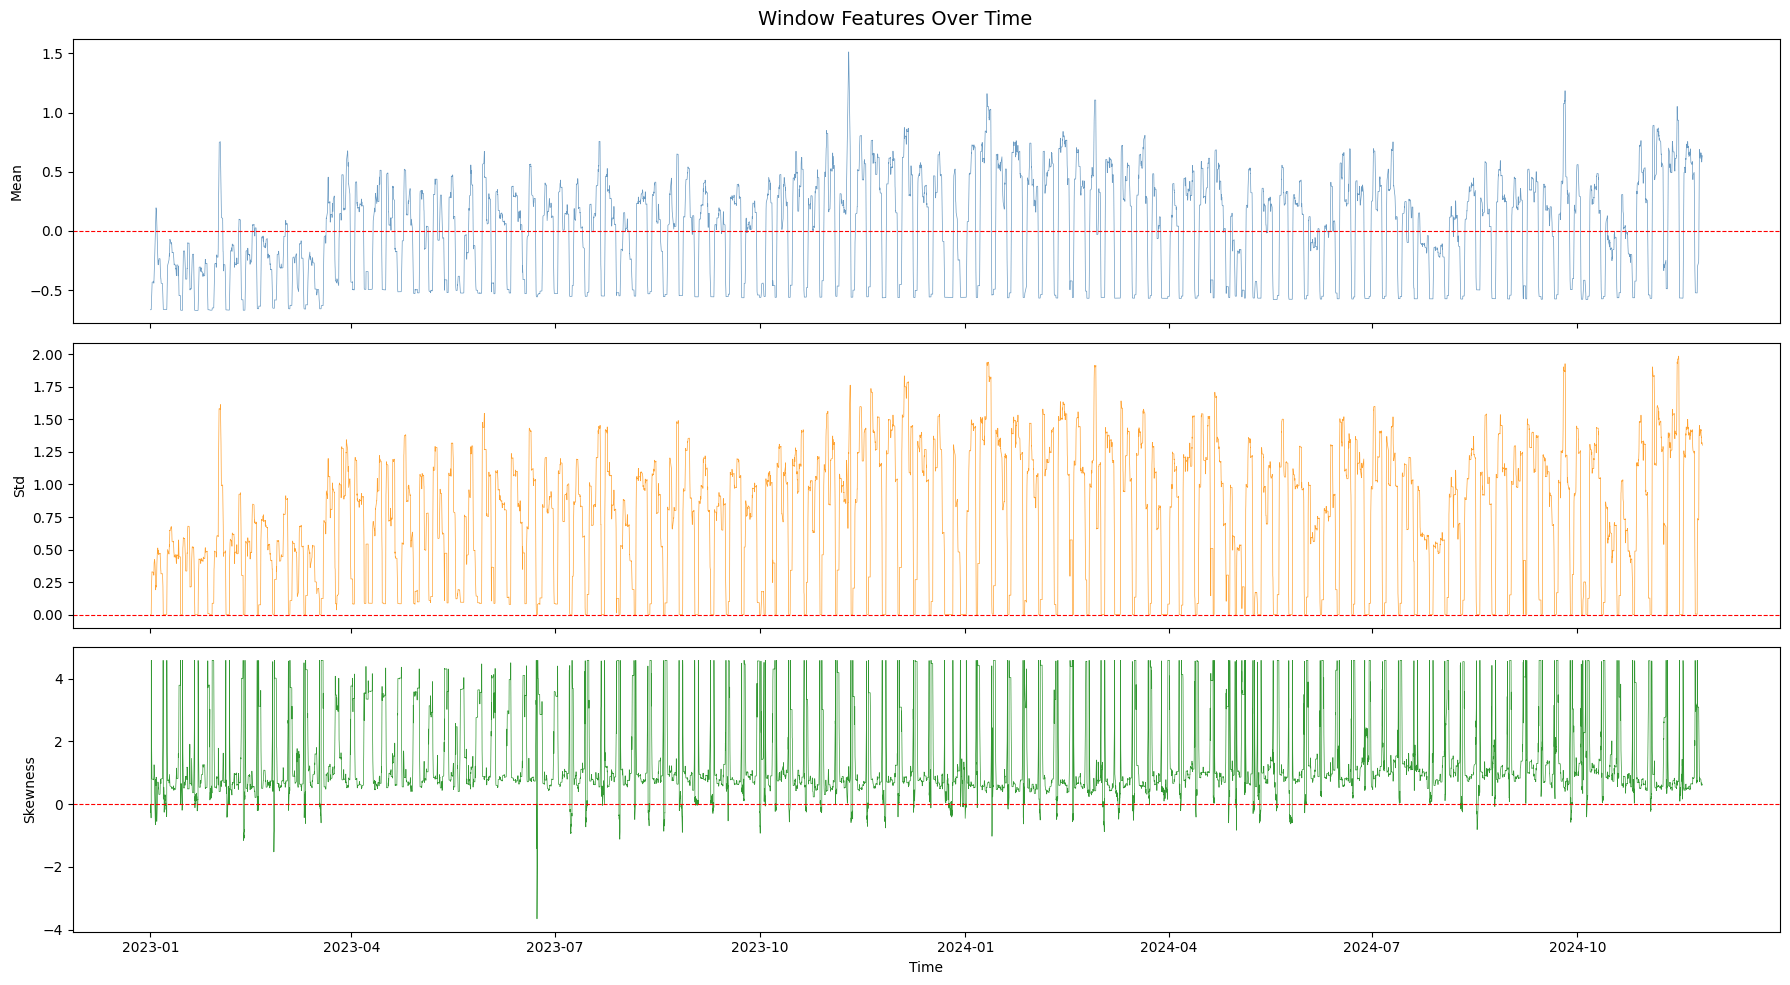

Saved.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
time_index = meta["index"][:len(feats)]
fig,axes=plt.subplots(3,1,figsize=(18,10),sharex=True)
fig.suptitle('Window Features Over Time',fontsize=14)
names=["Mean","Std","Skewness"]
colors=["steelblue","darkorange","green"]
for i,(name,color) in enumerate(zip(names,colors)):
    axes[i].plot(time_index,feats[:,i],color=color,linewidth=0.5,alpha=0.8)
    axes[i].set_ylabel(name)
    axes[i].axhline(0,color='red',linestyle="--",linewidth=0.8)
axes[2].set_xlabel("Time")
plt.tight_layout()
plt.savefig("features_over_time.png",dpi=150)
plt.show()
print("Saved.")

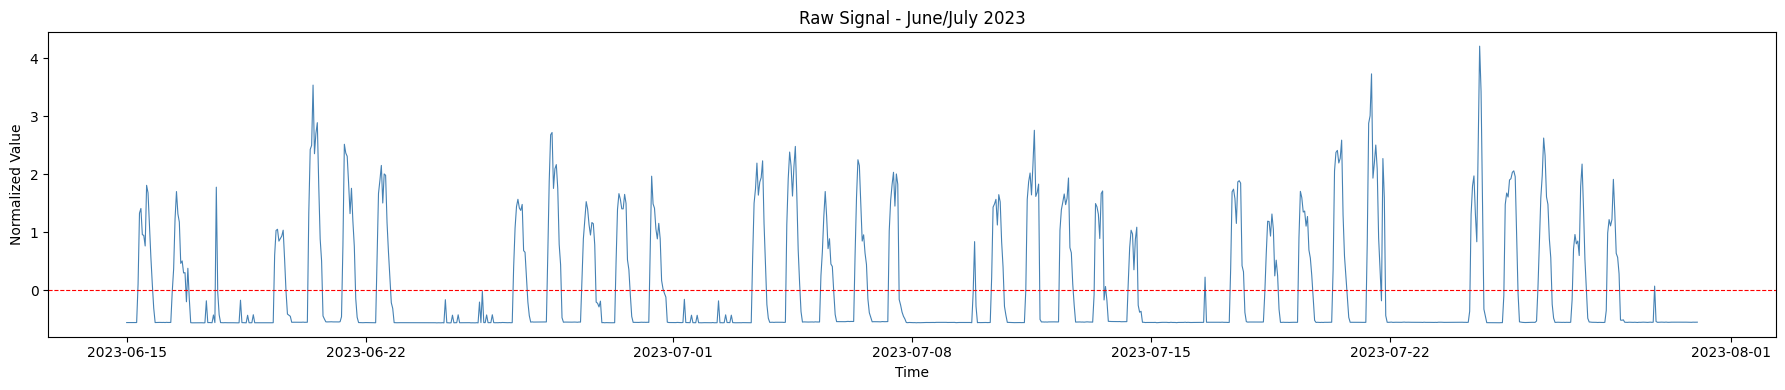

In [9]:
#zoom into July 2023
mask = (meta["index"] >= "2023-06-15") & (meta["index"] <= "2023-07-31")
july_values = meta["values_norm"][mask]
july_index = meta["index"][mask]
plt.figure(figsize=(18,4))
plt.plot(july_index,july_values,color='steelblue',linewidth=0.8)
plt.title('Raw Signal - June/July 2023')
plt.xlabel('Time')
plt.ylabel('Normalized Value')
plt.axhline(0,color='red',linestyle='--',linewidth=0.8)
plt.tight_layout()


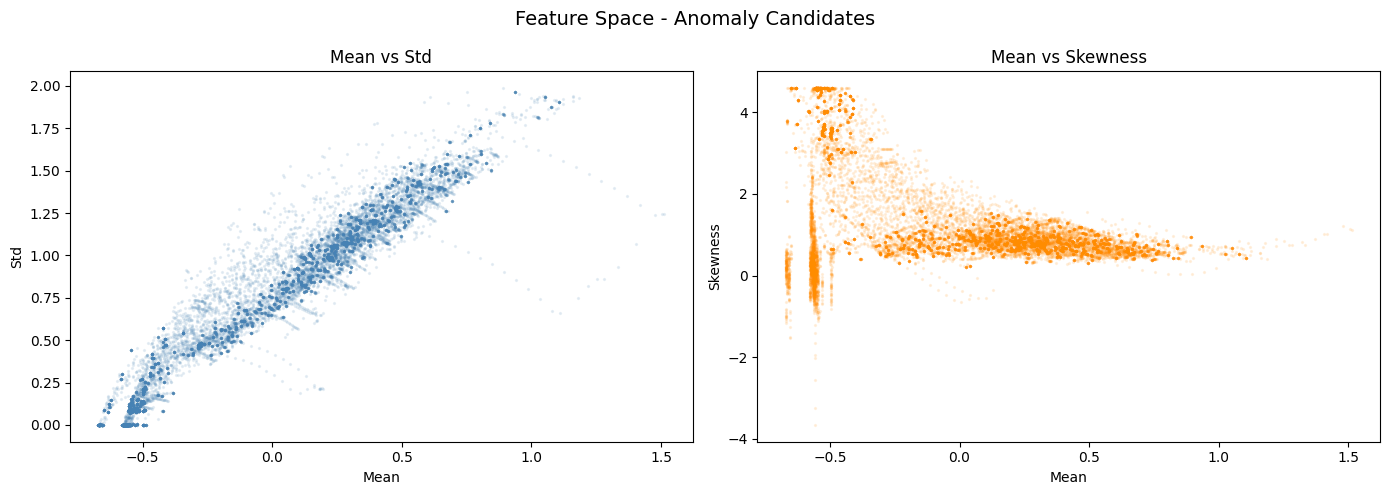

Saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Space - Anomaly Candidates", fontsize=14)
#mean vs std
axes[0].scatter(feats[:, 0], feats[:, 1], alpha=0.1, s=2, color="steelblue")
axes[0].set_xlabel("Mean")
axes[0].set_ylabel("Std")
axes[0].set_title("Mean vs Std")
#mean vs skewness
axes[1].scatter(feats[:, 0], feats[:, 2], alpha=0.1, s=2, color="darkorange")
axes[1].set_xlabel("Mean")
axes[1].set_ylabel("Skewness")
axes[1].set_title("Mean vs Skewness")

plt.tight_layout()
plt.savefig("feature_scatter.png", dpi=150)
plt.show()
print("Saved")
